In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


tickers = ["AAPL", "TSLA", "MSFT"]
start = "2020-01-01"

prices = yf.download(tickers, start=start, auto_adjust=True, progress=False)["Close"].dropna()

#daily % returns
rets = prices.pct_change().dropna()

#Correlation matrix
corr = rets.corr()
print("Correlation (daily returns):\n", corr.round(2))

Correlation (daily returns):
 Ticker  AAPL  MSFT  TSLA
Ticker                  
AAPL    1.00  0.72  0.50
MSFT    0.72  1.00  0.45
TSLA    0.50  0.45  1.00


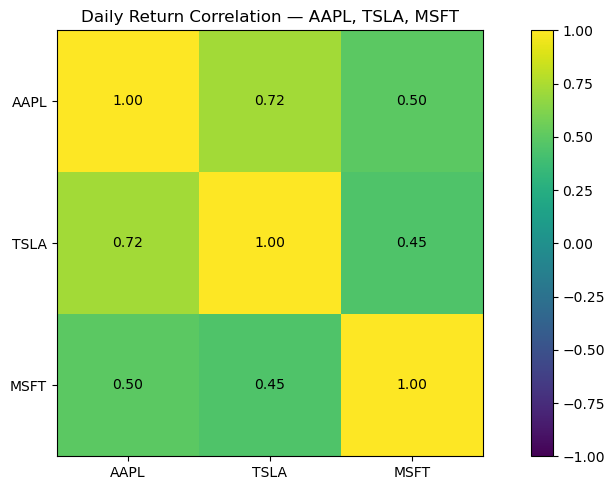

In [7]:
#Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(tickers)));
ax.set_xticklabels(tickers)
ax.set_yticks(range(len(tickers)))
ax.set_yticklabels(tickers)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i ,f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
ax.set_title("Daily Return Correlation — AAPL, TSLA, MSFT")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
